# Optimized+augmented PyTorch CNN

In this notebook, we train the winning CNN architecture from the Optuna run in notebook 04, using the optimized training strategy from notebook 05, on the CIFAR-10 dataset with image augmentation for improved generalization.

## Notebook set-up

### Imports

In [ ]:
# Standard library imports
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# Package imports
from image_classification_tools.pytorch import DataPipeline, AugmentationStrategy
import image_classification_tools.pytorch.evaluation as eval_utils
import image_classification_tools.pytorch.hyperparameter_optimization as optimization
import image_classification_tools.pytorch.plotting as plots
import image_classification_tools.pytorch.training as training

# Local imports
import configuration as config
import helper_functions as hf

Using device: cuda


### Hyperparameters

In [ ]:
# Model control
retrain_model = True        # Set to False to load existing model
model_source = 'local'      # 'local' to load from disk, 'huggingface' to download from Hub

## 1. Load optimization results

In [3]:
# Load architecture optimization study from notebook 04
architecture_study = optuna.load_study(
    study_name='architecture_optimization',
    storage=config.OPTUNA_STORAGE_URL
)

# Get best architecture parameters
arch_params = architecture_study.best_trial.params

print('Best architecture hyperparameters from notebook 04:\n')
for key, value in arch_params.items():
    print(f'  {key}: {value}')

print(f'\nBest validation accuracy: {architecture_study.best_trial.value:.2f}%')

# Load training optimization study from notebook 05
training_study = optuna.load_study(
    study_name='training_optimization',
    storage=config.OPTUNA_STORAGE_URL
)

# Get best training parameters
training_params = training_study.best_trial.params

print('\nBest training hyperparameters from notebook 05:\n')
for key, value in training_params.items():
    print(f'  {key}: {value}')

print(f'\nBest validation accuracy: {training_study.best_trial.value:.2f}%')

# Get batch size from architecture optimization
batch_size = arch_params['batch_size']


Best architecture hyperparameters from notebook 04:

  batch_size: 256
  n_conv_blocks: 7
  initial_filters: 64
  n_fc_layers: 1
  conv_dropout_rate: 0.3970168590808983
  fc_dropout_rate: 0.41794948916615016
  pool_frequency: 4
  filter_double_frequency: 3
  learning_rate: 0.0003262697843356068

Best validation accuracy: 88.79%

Best training hyperparameters from notebook 05:

  optimizer: SGD
  learning_rate: 0.010258532143373404
  weight_decay: 0.0021674627774374913
  label_smoothing: 0.003165204969827274
  lr_scheduler: step
  momentum: 0.9560066692269822
  nesterov: True

Best validation accuracy: 91.57%


## 2. Create data pipeline with pregenerated augmentation

The new `DataPipeline` handles augmentation automatically:
- Generates augmented data from the training set only (no data leakage)
- Caches augmented data for fast reuse
- Automatically splits train/val/test before augmentation

In [ ]:
# Create data pipeline with pregenerated augmentation
loaders = DataPipeline(
    data_source=datasets.CIFAR10,
    split='train/val/test',
    train_transform=config.RGB_TRANSFORM,
    eval_transform=config.RGB_TRANSFORM,
    augmentation=AugmentationStrategy.PREGENERATED,
    pil_augmentations=config.PIL_AUGMENTATIONS,
    tensor_augmentations=config.TENSOR_AUGMENTATIONS,
    n_augmentations=5,  # Generate 5 augmented copies per image
    preload='gpu',
    batch_size=batch_size,
    val_size=config.VAL_SIZE,
    seed=config.SEED,
    cache_key=config.AUGMENTATION_CACHE_KEY,
    root=config.DATA_DIR
).get_loaders()

# Display pipeline summary
print(loaders.split_info())
print(f'\nBatch sizes: {loaders.get_batch_sizes()}')

# Unpack loaders for convenience
train_loader = loaders.train
val_loader = loaders.val
test_loader = loaders.test

## 3. Build optimized CNN using best hyperparameters

Create a CNN using the best hyperparameters found during Optuna optimization, then train it with pre-augmented data.

### 3.1. Create model with best hyperparameters

In [ ]:
# Define model path
model_path = config.MODELS_DIR / 'augmented_cnn.pth'

# Load existing model if requested
if not retrain_model:
    model = hf.load_model_from_source(
        model_path=model_path,
        model_name='augmented_cnn.pth',
        model_source=model_source,
        device=config.DEVICE
    )
    
    if model is None:
        print('Pretrained model not available, proceeding with training...')
        retrain_model = True
else:
    print('Training new model...')

In [ ]:
if retrain_model:
    # Define the improved model
    model = training.ImprovedCNN(
        input_channels=3,
        num_classes=len(config.CLASS_NAMES),
        initial_channels=64,
        num_blocks=2
    ).to(config.DEVICE)

    # Show model architecture
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(model)
    print(f'\nTotal parameters: {total_params:,}')
    print(f'Trainable parameters: {trainable_params:,}')

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Dropout(p=0.3970168590808983, inplace=False)
  (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU()
  (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU()
  (13): Dropout(p=0.3970168590808983, inplace=False)
  (14): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (16): ReLU()
  (17): 

### 3.2. Define loss function and optimizer

Use the optimized training hyperparameters from notebook 05.

In [ ]:
%%time

if retrain_model:
    # Define optimizer and scheduler
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

    # Train model
    history = training.train(
        model=model, 
        criterion=criterion, 
        optimizer=optimizer,
        scheduler=scheduler,
        train_loader=train_loader,
        val_loader=val_loader, 
        device=config.DEVICE, 
        epochs=30,
        patience=5,
        print_every=250
    )

    print(f'\nTraining completed!')
    print(f'Best validation loss: {min(history["val_loss"]):.4f}')
    print(f'Best validation accuracy: {max(history["val_accuracy"]):.4f}')

    # Continue training with reduced learning rate
    print(f'\nContinuing training with reduced learning rate...')

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

    history2 = training.train(
        model=model, 
        criterion=criterion, 
        optimizer=optimizer,
        scheduler=scheduler,
        train_loader=train_loader,
        val_loader=val_loader, 
        device=config.DEVICE, 
        epochs=30,
        patience=5,
        print_every=250
    )

    print(f'\nTraining completed!')
    print(f'Best validation loss: {min(history2["val_loss"]):.4f}')
    print(f'Best validation accuracy: {max(history2["val_accuracy"]):.4f}')

    # Merge histories
    for key in history.keys():
        history[key].extend(history2[key])

    # Continue training with reduced learning rate
    print(f'\nContinuing training with reduced learning rate...')

    optimizer = optim.Adam(model.parameters(), lr=0.00005)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

    history3 = training.train(
        model=model, 
        criterion=criterion, 
        optimizer=optimizer,
        scheduler=scheduler,
        train_loader=train_loader,
        val_loader=val_loader, 
        device=config.DEVICE, 
        epochs=30,
        patience=5,
        print_every=250
    )

    print(f'\nTraining completed!')
    print(f'Best validation loss: {min(history3["val_loss"]):.4f}')
    print(f'Best validation accuracy: {max(history3["val_accuracy"]):.4f}')

    # Merge histories
    for key in history.keys():
        history[key].extend(history3[key])

    # Continue training with reduced learning rate
    print(f'\nContinuing training with reduced learning rate...')

    optimizer = optim.Adam(model.parameters(), lr=0.000025)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

    history4 = training.train(
        model=model, 
        criterion=criterion, 
        optimizer=optimizer,
        scheduler=scheduler,
        train_loader=train_loader,
        val_loader=val_loader, 
        device=config.DEVICE, 
        epochs=30,
        patience=5,
        print_every=250
    )

    print(f'\nTraining completed!')
    print(f'Best validation loss: {min(history4["val_loss"]):.4f}')
    print(f'Best validation accuracy: {max(history4["val_accuracy"]):.4f}')

    # Merge histories
    for key in history.keys():
        history[key].extend(history4[key])
    print()
else:
    print('Training skipped - using loaded model')

Using SGD optimizer:
  lr=0.010259
  weight_decay=0.002167
  momentum=0.9560066692269822
  nesterov=True

Using CrossEntropyLoss with label_smoothing=0.003
Using StepLR scheduler (step_size=30, gamma=0.1)


### 3.3. Train model

In [10]:
%%time

history = training.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=config.DEVICE,
    lazy_loading=True,  # Move data to device during training (not preloaded)
    epoch_scheduler=scheduler,  # Use scheduler from training optimization
    epochs=epochs,
    print_every=print_every,
    enable_early_stopping=True,
    early_stopping_patience=15  # More patience for scheduler warmup
)

print()

Epoch   1/500 - loss: 2.0136 - acc: 21.05% - val_loss: 2.7248 - val_acc: 13.60% - lr: 0.010259
Epoch  25/500 - loss: 0.7452 - acc: 75.35% - val_loss: 0.8449 - val_acc: 71.60% - lr: 0.010259
Epoch  50/500 - loss: 0.4617 - acc: 85.41% - val_loss: 0.4441 - val_acc: 85.73% - lr: 0.001026
Epoch  75/500 - loss: 0.3765 - acc: 88.26% - val_loss: 0.3856 - val_acc: 87.72% - lr: 0.000103
Epoch 100/500 - loss: 0.3611 - acc: 88.92% - val_loss: 0.3756 - val_acc: 87.82% - lr: 0.000010
Epoch 125/500 - loss: 0.3583 - acc: 88.93% - val_loss: 0.3836 - val_acc: 87.59% - lr: 0.000001
Epoch 150/500 - loss: 0.3599 - acc: 88.97% - val_loss: 0.3746 - val_acc: 87.96% - lr: 0.000000

Early stopping at epoch 151
Best val_loss: 0.3698 at epoch 136
Restored best model weights

CPU times: user 10h 14min 46s, sys: 50.7 s, total: 10h 15min 36s
Wall time: 5h 5min 7s


### 3.4. Learning curves

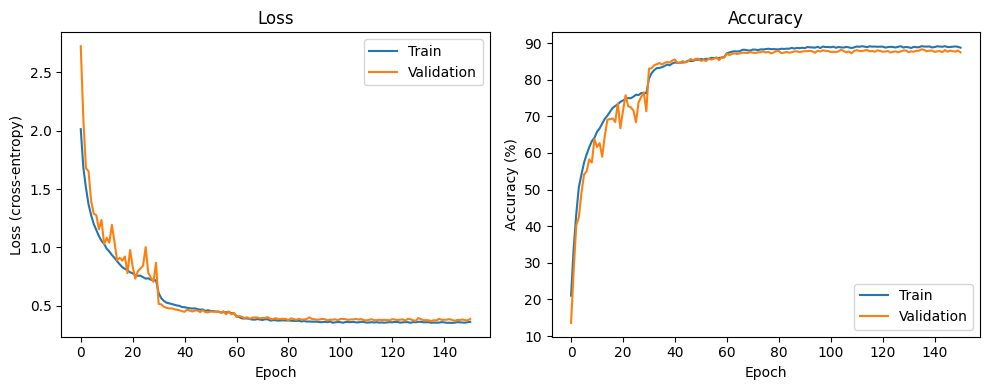

In [ ]:
if retrain_model:
    fig, (ax1, ax2) = plots.plot_learning_curves(history, metrics=['loss', 'accuracy'])
    plt.show()
else:
    print('Skipping learning curves - no training history available')

## 4. Evaluate model on test set

### 4.1. Calculate test accuracy

In [12]:
test_accuracy, predictions, true_labels = eval_utils.evaluate_model(model, test_loader)
print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 90.65%


### 4.2. Per-class accuracy

In [13]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in config.CLASS_NAMES}
class_total = {name: 0 for name in config.CLASS_NAMES}

for pred, true in zip(predictions, true_labels):

    class_name = config.CLASS_NAMES[true]
    class_total[class_name] += 1

    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in config.CLASS_NAMES:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 91.30%
automobile  : 95.80%
bird        : 87.60%
cat         : 79.30%
deer        : 91.50%
dog         : 83.20%
frog        : 93.60%
horse       : 93.80%
ship        : 95.30%
truck       : 95.10%


### 4.3. Confusion matrix

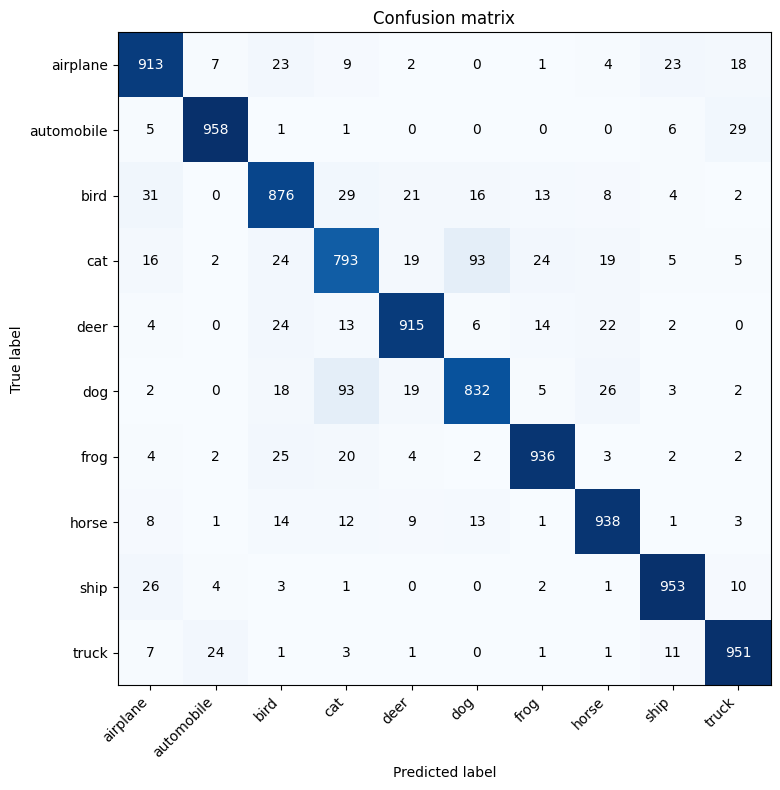

In [14]:
fig, ax = plots.plot_confusion_matrix(true_labels, predictions, config.CLASS_NAMES)
plt.show()

### 4.4. Predicted class probability distributions

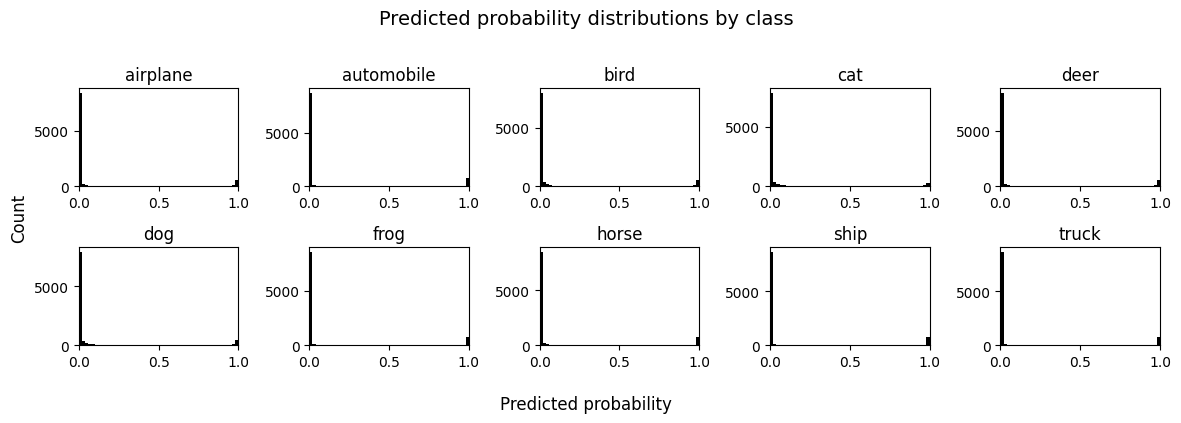

In [15]:
# Get predicted probabilities for all test samples
model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(config.DEVICE, non_blocking=True)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions
fig, axes = plots.plot_class_probability_distributions(all_probs, config.CLASS_NAMES)
plt.show()

### 4.5. Evaluation curves

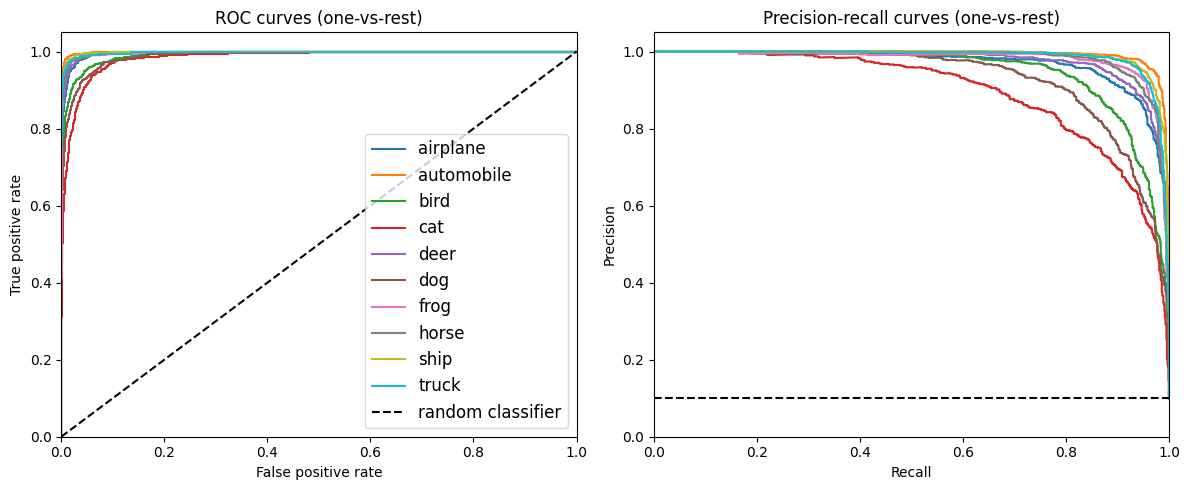

In [16]:
fig, (ax1, ax2) = plots.plot_evaluation_curves(true_labels, all_probs, config.CLASS_NAMES)
plt.show()

## 5. Save model

In [ ]:
if retrain_model:

    # Save trained model (and auto-upload to Hugging Face if configured)
    # Note: This notebook saves state_dict instead of full model
    torch.save(model.state_dict(), model_path)
    print(f'Model state dict saved to: {model_path}')
    
    # Upload if configured
    if hf.should_upload_to_huggingface():
        hf.upload_to_huggingface(model_path, 'augmented_cnn.pth')

Model saved to: ../models/pytorch/augmented_cnn.pth
Test accuracy: 90.65%


### 5.1. Upload to Hugging Face Hub (optional)

In [ ]:
# Upload model to Hugging Face Hub
# Note: Run 'huggingface-cli login' first to authenticate

upload_to_hf = False  # Set to True to enable upload

if upload_to_hf:
    config.upload_to_huggingface(
        model_path=model_path,
        model_name='augmented_cnn.pth',
        commit_message=f'Augmented CNN - Test accuracy: {test_accuracy:.2f}%'
    )

## 6. Save test results for comparison

In [18]:
# Save results path
results_path = config.RESULTS_DIR / 'augmented_cnn_results.pkl'

# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create results dictionary
results_dict = {
    'true_labels': true_labels,
    'predictions': predictions,
    'all_probs': all_probs,
    'test_accuracy': test_accuracy,
    'total_params': total_params,
    'trainable_params': trainable_params
}

# Save results
with open(results_path, 'wb') as f:
    pickle.dump(results_dict, f)

print(f'Test results saved to: {results_path}')
print(f'  - Test accuracy: {test_accuracy:.2f}%')
print(f'  - Total parameters: {total_params:,}')
print(f'  - Trainable parameters: {trainable_params:,}')

Test results saved to: ../data/pytorch/performance_results/augmented_cnn_results.pkl
  - Test accuracy: 90.65%
  - Total parameters: 1,920,970
  - Trainable parameters: 1,920,970
